# Configuración básica (no tocar)

In [757]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [758]:
x = Variable()

# Implementación de métodos

In [759]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    if df.eval(a) * df.eval(b) >= 0:
        raise ValueError("La función no cambia de signo en el intervalo [a, b]")

    for iteraciones in range(max_iter):
        iteraciones += 1
        xn = (a + b) / 2

        if -tol < df.eval(xn) < tol:  
            return xn, iteraciones
        
        if df.eval(a) * df.eval(xn) < 0:  
            b = xn
        else:  
            a = xn
    return xn, iteraciones

def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    ddf = df.derivative()
    xn = x0

    for iteraciones in range(max_iter):
        fx= df.eval(xn)
        
        if -tol < fx < tol:  
            return xn, iteraciones
        
        dfx = ddf.eval(xn)

        if -tol < dfx < tol:
            raise ZeroDivisionError(
                "Segunda derivada cercana a cero"
            )
        xn = xn - fx / dfx

    return xn, iteraciones
    

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0
    
    for iteraciones in range(max_iter):
        fx = df.eval(xn)
        
        if abs(fx) < tol:  
            return xn, iteraciones
        
        xn = xn - lr * fx
    return xn, iteraciones

print(biseccion(x**2,-1,1))
print(biseccion((x + 0.5)**3 - x - 0.5,-1,1))
print(biseccion(-cos(x),-1,1))

print(newton(x**2, 1))
print(newton((x + 0.5)**3 - x - 0.5, 1))
print(newton(-cos(x), 1))

print(descenso_gradiente(x**2, 1, lr=1e-2))
print(descenso_gradiente((x + 0.5)**3 - x - 0.5, 1, lr=1e-2))
print(descenso_gradiente(-cos(x), 1, lr=1e-2))


(0.0, 1)
(0.07735013961791992, 22)
(0.0, 1)
(0.0, 1)
(0.07735026919569789, 5)
(np.float64(2.923566201412306e-13), 4)
(4.915281814827202e-07, 719)
(0.07735055352487515, 408)
(np.float64(4.723143234180145e-05), 999)


### Prueba de métodos

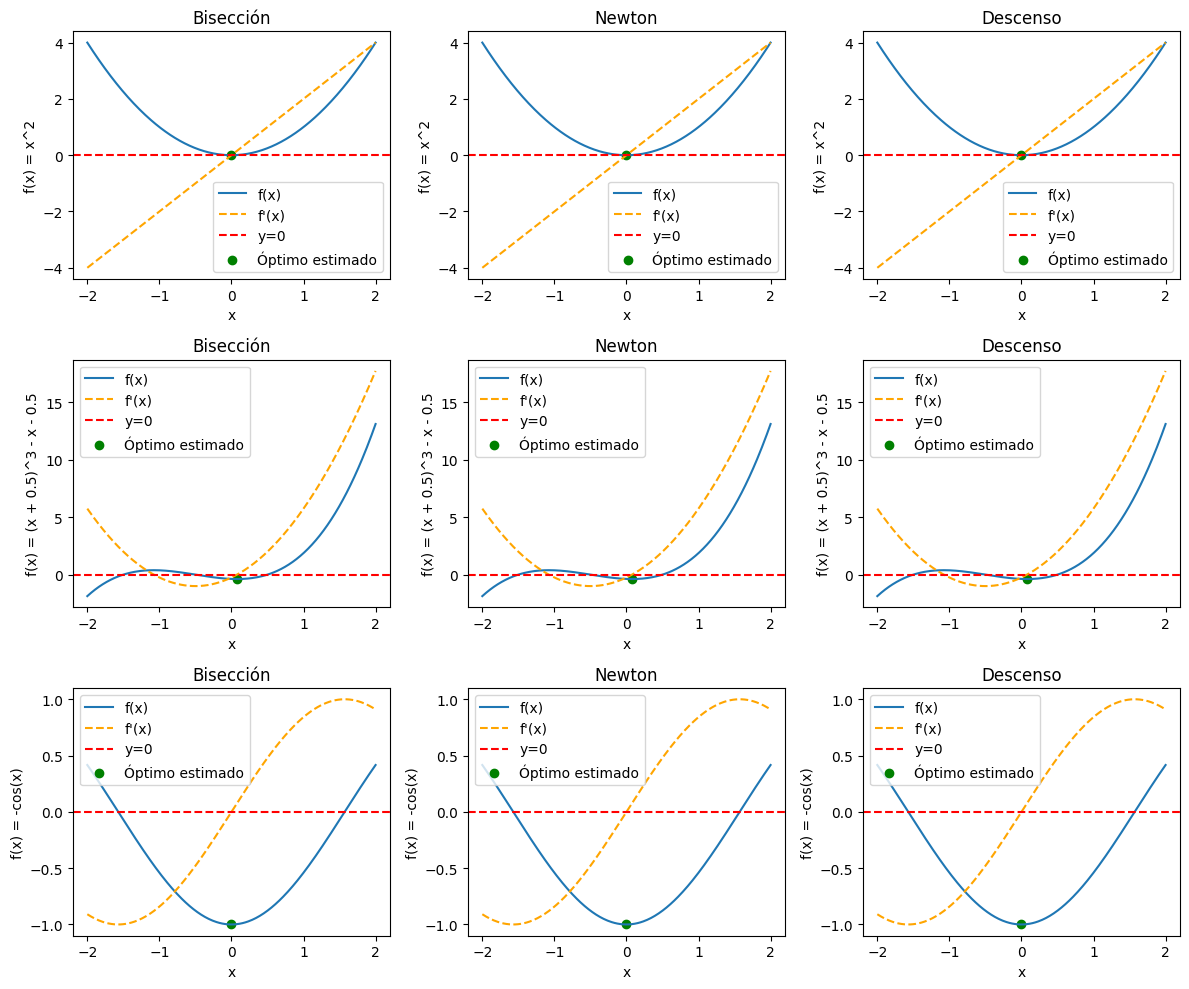

In [760]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

# Aplicación a función no trivial

In [761]:
f = x**2 + 2*sin(3*x)

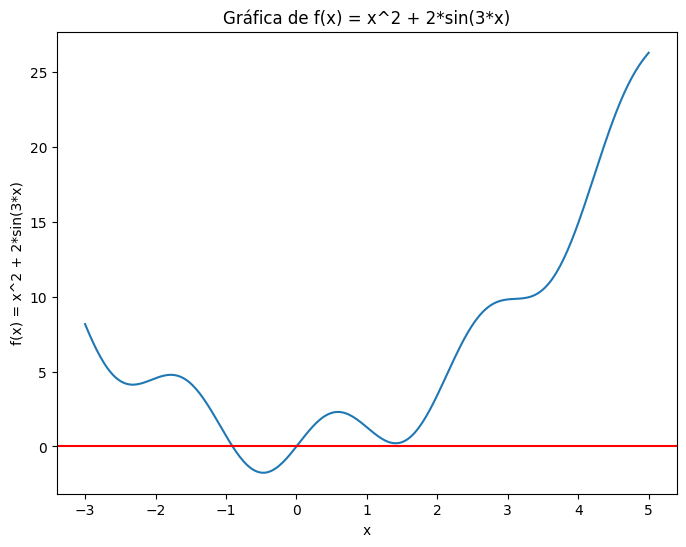

In [762]:
# Grafica de la función

lp = np.linspace(-3, 5, 300)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_xlabel("x")
ax.set_ylabel("f(x) = x^2 + 2*sin(3*x)")


ax.plot(lp, [f.eval(x) for x in lp])
ax.axhline(0, color="red")
ax.plot()

plt.title("Gráfica de f(x) = x^2 + 2*sin(3*x)")
plt.show()

In [ ]:
# Analisis de casos 
casos = []

pred_bis = [
    "Convergencia incierta",
    "Se espera convergencia",
    "Convergencia incierta"
]

for (a, b), pred in zip([(-2, 1), (-1, 0), (1, 2)], pred_bis):
    x, it = biseccion(f, a, b)
    casos.append([
        "Bisección",
        f"[{a}, {b}]",
        pred,
        x,
        it
    ])

pred_newton = [
    "Convergencia hacia un punto crítico",
    "Convergencia hacia un punto crítico",
    "Convergencia incierta"
]

for x0, pred in zip([-2, -1, 4], pred_newton):
    x, it = newton(f, x0)
    casos.append([
        "Newton",
        f"x0={x0}",
        pred,
        x,
        it
    ])

pred_grad = [
    "Avanza hacia un mínimo",
    "Cerca de punto crítico",
    "Avanza hacia un mínimo"
]

lr = 0.01
for x0, pred in zip([-3, 0.585, 4], pred_grad):
    x, it = descenso_gradiente(f, x0, lr)
    casos.append([
        "Gradiente",
        f"x0={x0}",
        pred,
        x,
        it
    ])

tabla1 = pd.DataFrame(
    casos,
    columns=[
        "Método",
        "Condición inicial",
        "Predicción",
        "Aproximación",
        "Iteraciones"
    ]
)

print(tabla1)

      Método Condición inicial                Predicción  Aproximación  \
0  Bisección           [-2, 1]     Convergencia incierta     -1.782932   
1  Bisección           [-1, 0]    Se espera convergencia     -0.471043   
2  Bisección            [1, 2]     Convergencia incierta      1.407957   
3     Newton             x0=-2  Converge a raíz negativa     -1.782932   
4     Newton             x0=-1   Converge a raíz cercana      0.589531   
5     Newton              x0=4     Convergencia incierta      7.820892   
6  Gradiente             x0=-3    Avanza hacia un mínimo     -2.322807   
7  Gradiente          x0=0.585    Cerca de punto crítico     -0.471043   
8  Gradiente              x0=4    Avanza hacia un mínimo      1.407957   

   Iteraciones  
0           23  
1           24  
2           21  
3            5  
4            4  
5          999  
6          108  
7          109  
8          202  


In [764]:
# Analisis de casos con distintos learning rates
casos_distintos_lr = []

for x0 in [-3, 0.585, 4]:
    for lr in [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1]:
        x, it = descenso_gradiente(f, x0, lr)
        casos_distintos_lr.append([
            "Gradiente",
            lr,
            f"x0={x0}",
            x,
            it
        ]
    )

tabla2 = pd.DataFrame(
    casos_distintos_lr,
    columns=[
        "Método",
        "Learning Rate",
        "Condición inicial",
        "Aproximación",
        "Iteraciones"
    ]
)

print(tabla2)

       Método  Learning Rate Condición inicial  Aproximación  Iteraciones
0   Gradiente         0.0001             x0=-3     -2.443256          999
1   Gradiente         0.0010             x0=-3     -2.322808          999
2   Gradiente         0.0100             x0=-3     -2.322807          108
3   Gradiente         0.0500             x0=-3     -2.322807           14
4   Gradiente         0.1000             x0=-3     -2.322807           17
5   Gradiente         0.5000             x0=-3     -2.375674          999
6   Gradiente         1.0000             x0=-3   -181.523638          999
7   Gradiente         0.0001          x0=0.585      0.567770          999
8   Gradiente         0.0010          x0=0.585     -0.471042          999
9   Gradiente         0.0100          x0=0.585     -0.471043          109
10  Gradiente         0.0500          x0=0.585     -0.471043           14
11  Gradiente         0.1000          x0=0.585     -0.471043          612
12  Gradiente         0.5000          

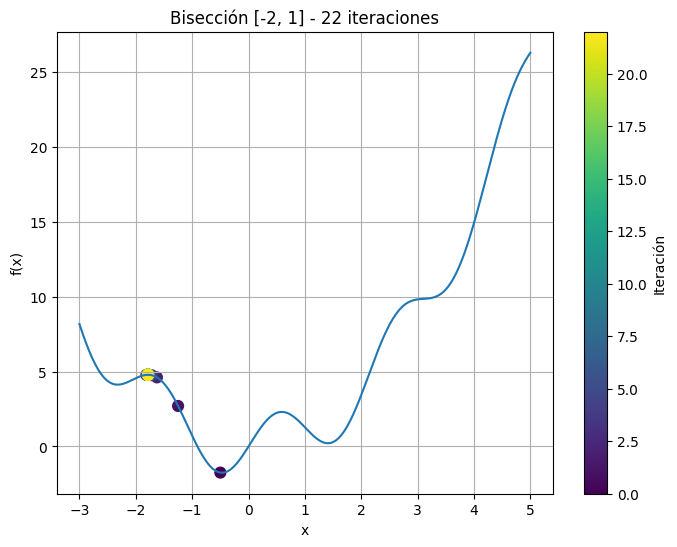

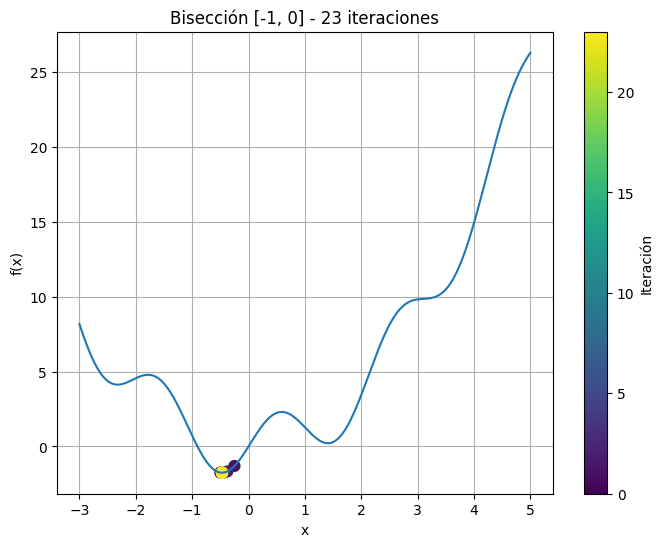

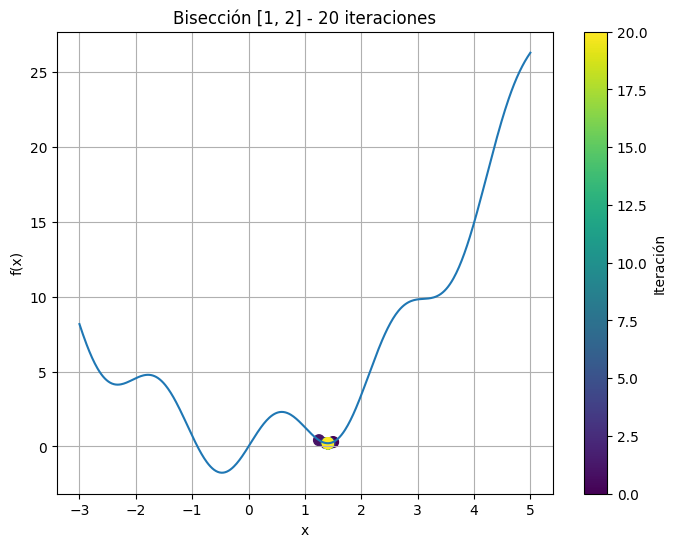

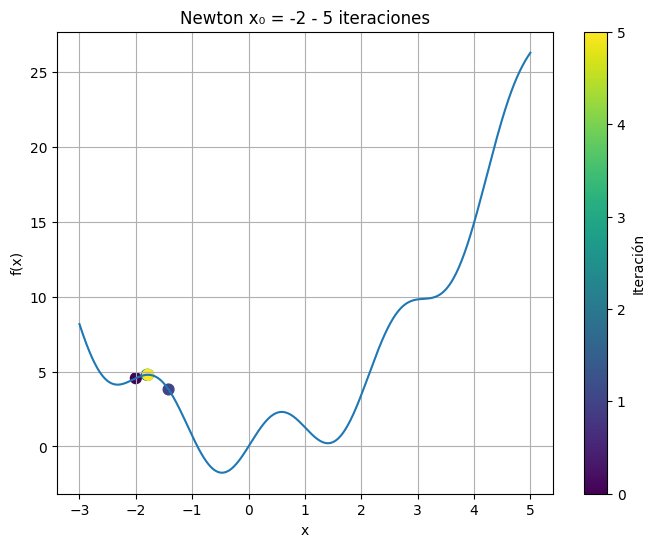

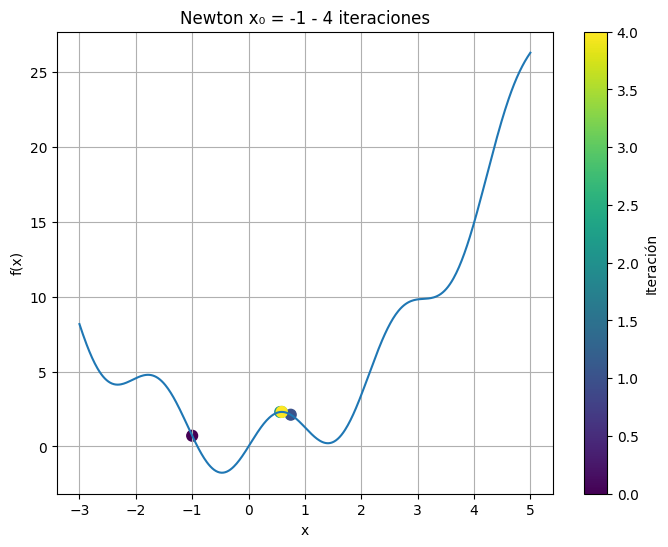

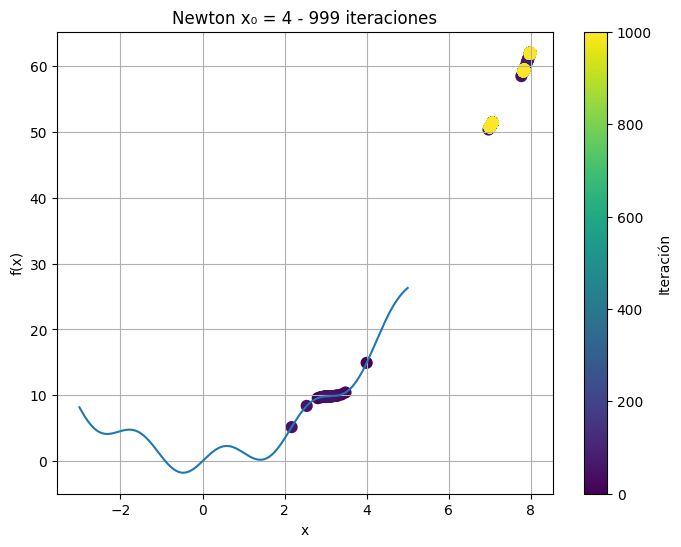

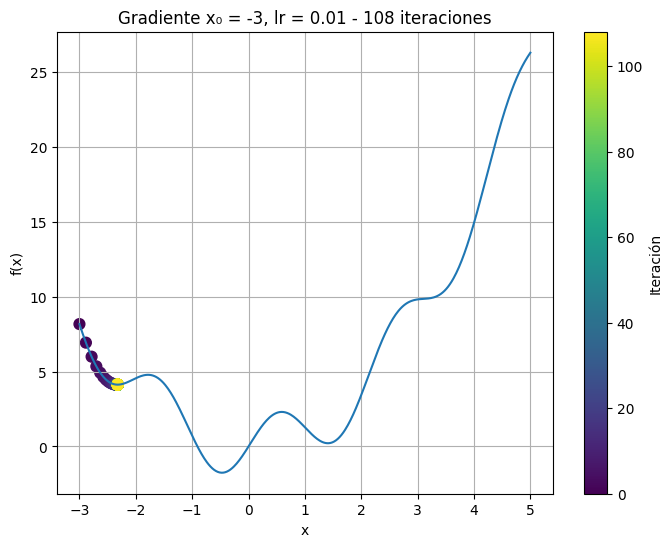

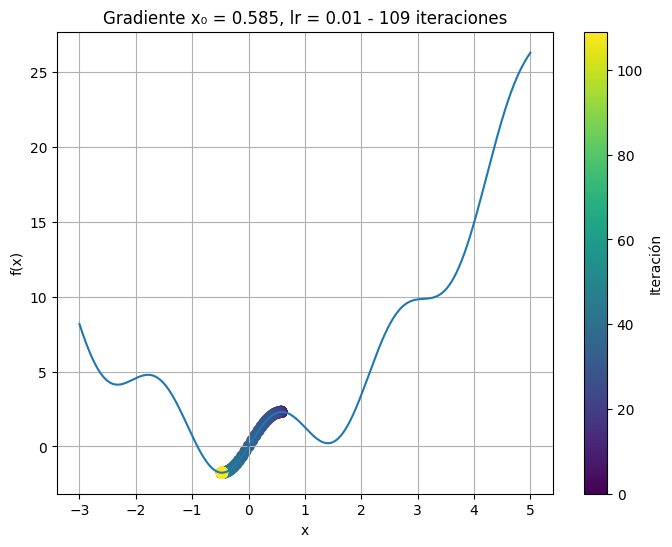

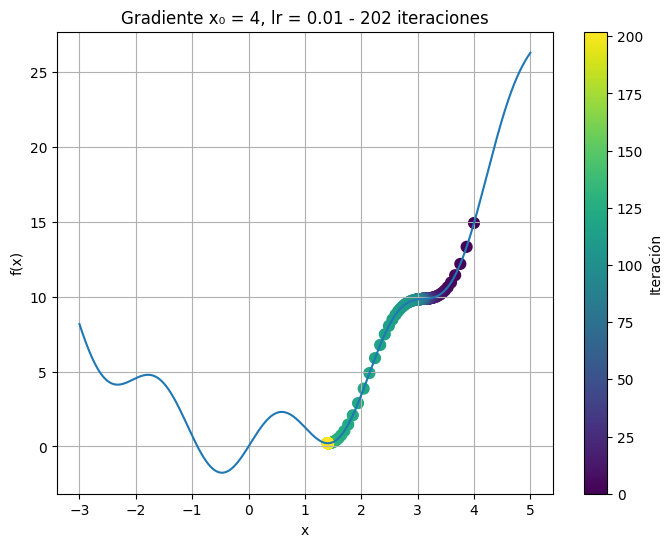

In [765]:
#Aplicación a función no trivial (Bonus)

def biseccion_sucecion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    if df.eval(a) * df.eval(b) >= 0:
        raise ValueError("La función no cambia de signo en el intervalo [a, b]")

    historial = []

    for iteraciones in range(max_iter):
        xn = (a + b) / 2
        historial.append(xn)
        
        if -tol < df.eval(xn) < tol:  
            return xn, iteraciones, historial
        
        if df.eval(a) * df.eval(xn) < 0:  
            b = xn
        else:  
            a = xn

    return xn, iteraciones, historial

def newton_sucecion(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    ddf = df.derivative()
    xn = x0

    historial = []
    historial.append(xn)

    for iteraciones in range(max_iter):
        fx= df.eval(xn)
        
        if -tol < fx < tol:  
            return xn, iteraciones, historial
        
        dfx = ddf.eval(xn)

        if -tol < dfx < tol:
            raise ZeroDivisionError(
                "Segunda derivada cercana a cero"
            )
        xn = xn - fx / dfx
        historial.append(xn)

    return xn, iteraciones, historial

def descenso_gradiente_sucecion(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0
    historial = []
    historial.append(xn)

    for iteraciones in range(max_iter):
        fx = df.eval(xn)
        
        if -tol < fx < tol:  
            return xn, iteraciones, historial
        
        xn = xn - lr * fx
        historial.append(xn)
    return xn, iteraciones, historial   

def graficar_evolucion(f, historial, titulo):

    xs = np.linspace(-3, 5, 500)

    plt.figure(figsize=(8,6))

    plt.plot(
        xs,
        [f.eval(x) for x in xs],
        label="f(x)"
    )

    plt.scatter(
        historial,
        [f.eval(x) for x in historial],
        c=np.arange(len(historial)),
        cmap="viridis",
        s=60
    )

    plt.colorbar(label="Iteración")

    plt.title(titulo)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)

    plt.show()

for a, b in [(-2, 1), (-1, 0), (1, 2)]:
    x, it, hist = biseccion_sucecion(f, a, b)

    graficar_evolucion(
        f,
        hist,
        f"Bisección [{a}, {b}] - {it} iteraciones"
    )


for x0 in [-2, -1, 4]:
    x, it, hist = newton_sucecion(f, x0)

    graficar_evolucion(
        f,
        hist,
        f"Newton x₀ = {x0} - {it} iteraciones"
    )


lr = 0.01

for x0 in [-3, 0.585, 4]:
    x, it, hist = descenso_gradiente_sucecion(
        f,
        x0,
        lr
    )

    graficar_evolucion(f,hist,f"Gradiente x₀ = {x0}, lr = {lr} - {it} iteraciones")


# Ajuste de datos

In [794]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()


In [ ]:
# Genere la función de pérdida
def funcion_perdida(modelo, df):
    x_data = df["x"].values
    y_data = df["y"].values

    N = len(x_data)
    perdida = 0

    for i in range(N):
        xi = x_data[i]
        yi = y_data[i]
        prediccion = modelo(xi, w)
        error = prediccion - yi
        perdida = perdida + (error ** 2)

    return perdida/N



def modelo_lineal(x, w):
    return w * x

def modelo_exp(x, w):
    return exp(w * x)

def modelo_sin(x, w):
    return sin(w * x)


w óptimo (Productoria): 0 | Iteraciones: 0


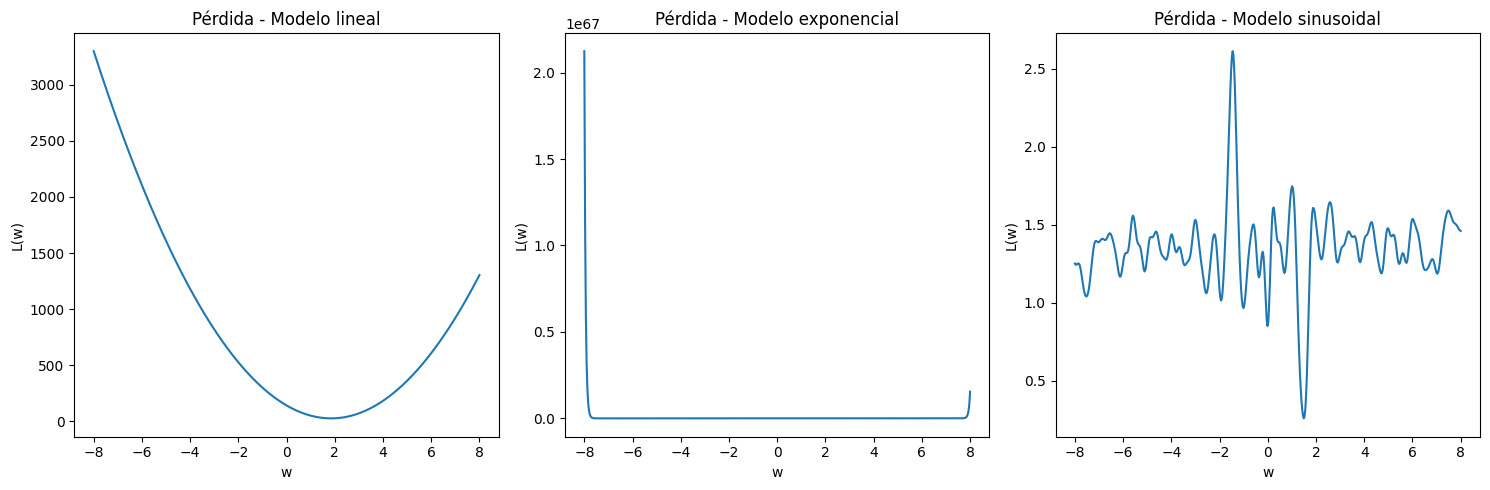

In [768]:
L_linear = funcion_perdida(modelo_lineal, df_linear)
L_exp = funcion_perdida(modelo_exp, df_exp)
L_sin = funcion_perdida(modelo_sin, df_sin)

w_values = np.linspace(-8, 8, 500)

losses = [L_linear, L_exp, L_sin]

titles = [
    "Pérdida - Modelo lineal",
    "Pérdida - Modelo exponencial",
    "Pérdida - Modelo sinusoidal"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, L in enumerate(losses):

    ax = axes[i]

    y = [L.eval(w) for w in w_values]

    ax.plot(w_values, y)

    ax.set_xlabel("w")
    ax.set_ylabel("L(w)")
    ax.set_title(titles[i])

plt.tight_layout()
plt.show()

In [769]:
#Obtener el w óptimo para algún learning rate
L_linear = funcion_perdida(modelo_lineal, df_linear)
L_exp = funcion_perdida(modelo_exp, df_exp)
L_sin = funcion_perdida(modelo_sin, df_sin)

w_opt_linear, it_linear = descenso_gradiente(L_linear, x0 = 0, lr=0.001)
w_opt_exp, it_exp = descenso_gradiente(L_exp, x0 = 0, lr=0.001)
w_opt_sin, it_sin = descenso_gradiente(L_sin, x0 = 0, lr=0.001)

print(f"Modelo lineal: w óptimo = {w_opt_linear}, lr = {lr}, iteraciones = {it_linear}")
print(f"Modelo exponencial: w óptimo = {w_opt_exp}, lr = {lr}, iteraciones = {it_exp}")
print(f"Modelo sinusoidal: w óptimo = {w_opt_sin}, lr = {lr}, iteraciones = {it_sin}")


Modelo lineal: w óptimo = 1.8479936159266037, lr = 0.01, iteraciones = 267
Modelo exponencial: w óptimo = 0.21257607800858003, lr = 0.01, iteraciones = 16
Modelo sinusoidal: w óptimo = -0.01070158577841339, lr = 0.01, iteraciones = 196


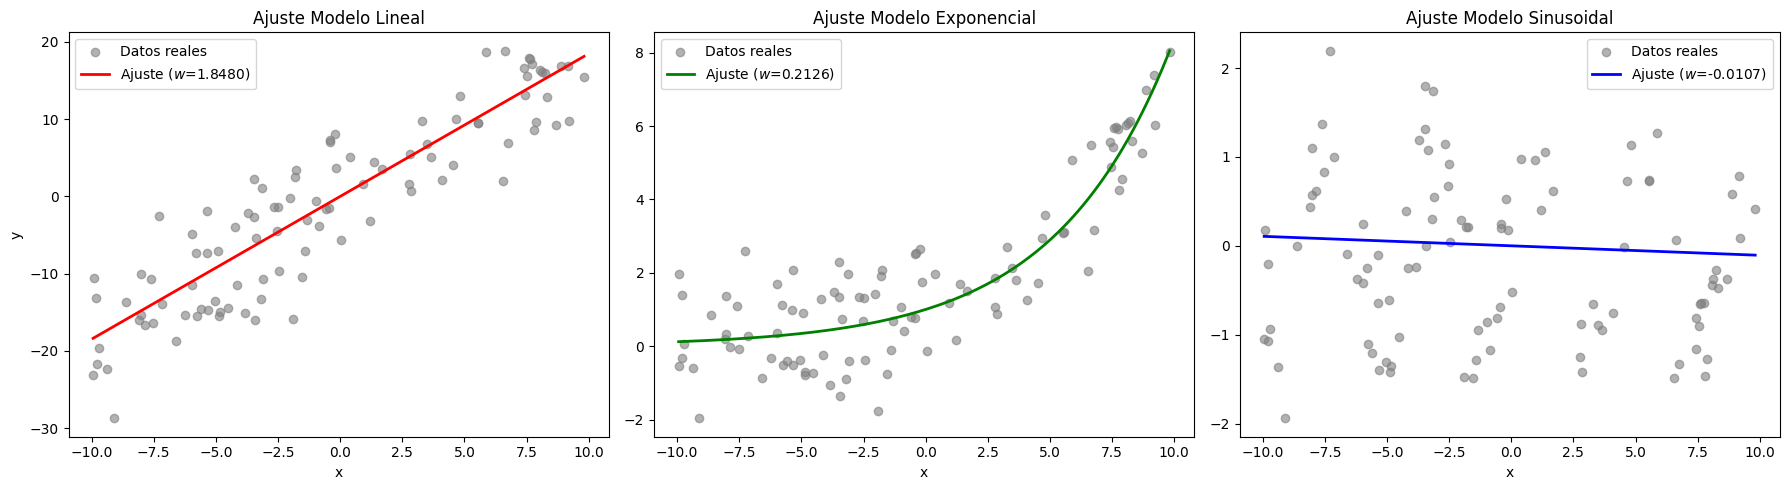

In [770]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.scatter(df_linear["x"], df_linear["y"], color="gray", alpha=0.6, label="Datos reales")
x_plot = np.linspace(df_linear["x"].min(), df_linear["x"].max(), 200)
y_plot = modelo_lineal(x_plot, w_opt_linear) 
ax.plot(x_plot, y_plot, color="red", linewidth=2, label=f"Ajuste ($w$={w_opt_linear:.4f})")
ax.set_title("Ajuste Modelo Lineal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()


ax = axes[1]
ax.scatter(df_exp["x"], df_exp["y"], color="gray", alpha=0.6, label="Datos reales")
x_plot = np.linspace(df_exp["x"].min(), df_exp["x"].max(), 200)
y_plot = np.exp(w_opt_exp * x_plot) 
ax.plot(x_plot, y_plot, color="green", linewidth=2, label=f"Ajuste ($w$={w_opt_exp:.4f})")
ax.set_title("Ajuste Modelo Exponencial")
ax.set_xlabel("x")
ax.legend()

ax = axes[2]
ax.scatter(df_sin["x"], df_sin["y"], color="gray", alpha=0.6, label="Datos reales")
x_plot = np.linspace(df_sin["x"].min(), df_sin["x"].max(), 500) 
y_plot = np.sin(w_opt_sin * x_plot) 
ax.plot(x_plot, y_plot, color="blue", linewidth=2, label=f"Ajuste ($w$={w_opt_sin:.4f})")
ax.set_title("Ajuste Modelo Sinusoidal")
ax.set_xlabel("x")
ax.legend()

plt.tight_layout()
plt.show()

# BONUS (5.1)       

L_lineal_gd: 1.8458874381373445
L_exp_gd: 0.2125760771682801
L_sin_gd: -0.010688402552831829
L_lineal_sgd: 1.8976458048403972
L_exp_sgd: 0.21106337191475227
L_sin_sgd: -0.025669185793167824


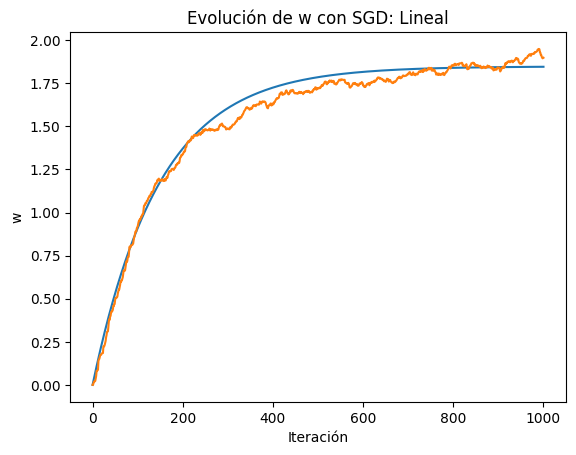

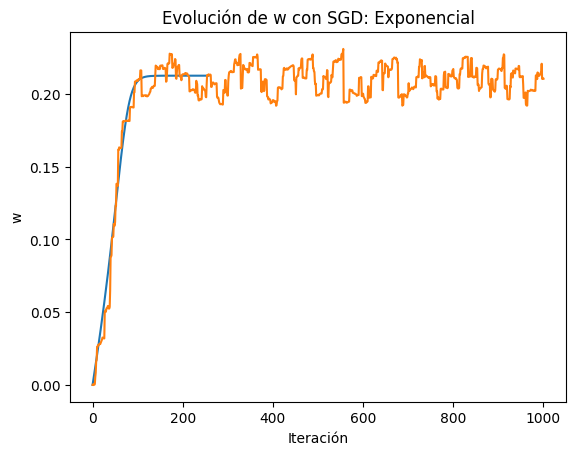

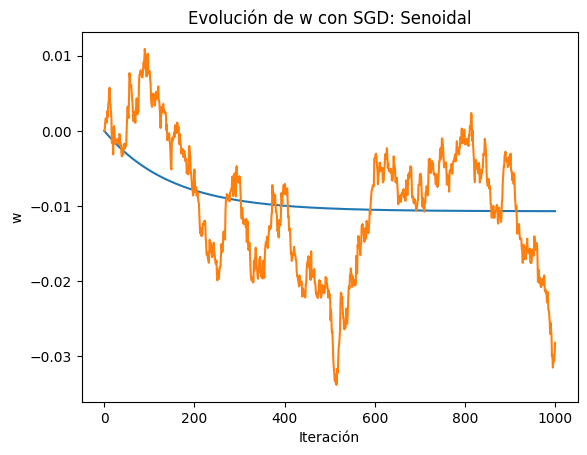

In [771]:
def perdida(modelo, x, y):
    pred = modelo(x, w)     
    return ((pred - y) ** 2)
    

def sgd(modelo, df, x0, lr,tol=1e-6, max_iter=1000):
    x_data = df["x"].values
    y_data = df["y"].values

    N = len(x_data)
    xn = x0
    historia = []
    historia.append(xn)

    for _ in range(max_iter):
        i = np.random.randint(0, N)
        xi = x_data[i]
        yi = y_data[i]
        prediccion = perdida(modelo, xi, yi)
        dprediccion = prediccion.derivative()
        gradiente = dprediccion.eval(xn)
        historia.append(xn)
        if abs(gradiente) < tol:
            return xn, historia
        xn = xn - lr * gradiente 

    return xn, historia

def gd(modelo, df, x0, lr, tol=1e-6, max_iter=1000):

    L = funcion_perdida(modelo, df)
    dL = L.derivative()

    xn = x0
    historia = [xn]

    for _ in range(max_iter):

        gradiente = dL.eval(xn)

        if abs(gradiente) < tol:
            return xn, historia
        
        xn = xn - lr * gradiente
        historia.append(xn)

    return xn, historia


L_linear_sgd, hist_linear_sgd = sgd(modelo_lineal, df_linear, x0=0, lr=0.0001)
L_exp_sgd, hist_exp_sgd = sgd(modelo_exp, df_exp, x0=0, lr=0.0001)
L_sin_sgd, hist_sin_sgd = sgd(modelo_sin, df_sin, x0=0, lr=0.0001)
L_linear_gd, hist_linear_gd = gd(modelo_lineal, df_linear, x0=0, lr=0.0001)
L_exp_gd, hist_exp_gd = gd(modelo_exp, df_exp, x0=0, lr=0.0001)
L_sin_gd, hist_sin_gd = gd(modelo_sin, df_sin, x0=0, lr=0.0001)

print(f"L_lineal_gd: {L_linear_gd}")
print(f"L_exp_gd: {L_exp_gd}")
print(f"L_sin_gd: {L_sin_gd}")
print(f"L_lineal_sgd: {L_linear_sgd}")
print(f"L_exp_sgd: {L_exp_sgd}")
print(f"L_sin_sgd: {L_sin_sgd}")

plt.plot(hist_linear_gd)
plt.plot(hist_linear_sgd)
plt.xlabel("Iteración")
plt.ylabel("w")
plt.title("Evolución de w con SGD: Lineal")
plt.show()

plt.plot(hist_exp_gd)
plt.plot(hist_exp_sgd)
plt.xlabel("Iteración")
plt.ylabel("w")
plt.title("Evolución de w con SGD: Exponencial")
plt.show()

plt.plot(hist_sin_gd)
plt.plot(hist_sin_sgd)
plt.xlabel("Iteración")
plt.ylabel("w")
plt.title("Evolución de w con SGD: Senoidal")
plt.show()

In [772]:
# Descenso por gradiente con learning rate variable
x = Variable()
f = x**2 + 2*sin(3*x)

def descenso_gradiente_variable(f: Function,x0: float,lr0: float,beta: float = 0.01,tol: float = 1e-6,max_iter: int = 1000):
    df = f.derivative()
    xn = x0

    for iteraciones in range(max_iter):
        grad = df.eval(xn)

        if abs(grad) < tol:
            return xn, iteraciones

        lr = lr0 / (1 + beta * iteraciones)

        xn = xn - lr * grad

    return xn, max_iter

casos_variable = []
lr = 0.01
for x0 in [-3, 0.585, 4]:
    x, it = descenso_gradiente_variable(f, x0, lr0=0.1)
    casos_variable.append([
        "Gradiente Variable",
        f"x0={x0}",
        "ver análisis",
        x,
        it
    ])

tabla3 = pd.DataFrame(
    casos_variable,
    columns=[
        "Método",
        "Condición inicial",
        "Predicción",
        "Aproximación",
        "Iteraciones"
    ]
)

print(tabla3)



               Método Condición inicial    Predicción  Aproximación  \
0  Gradiente Variable             x0=-3  ver análisis     -2.322807   
1  Gradiente Variable          x0=0.585  ver análisis     -0.471043   
2  Gradiente Variable              x0=4  ver análisis      1.407957   

   Iteraciones  
0           14  
1           35  
2           27  


In [796]:
#Formulaci´on producto de exponenciales vs suma
w = Variable()

def funcion_perdida_producto(df):
    x_data = df["x"].values
    y_data = df["y"].values

    N = len(x_data)
    perdida = 1

    for i in range(N):
        xi = x_data[i]
        yi = y_data[i]
        error = (modelo_lineal(xi, w) - yi)
        perdida *= exp(-(error**2))

    return perdida

L_prod = funcion_perdida_producto(df_linear)

L_prod_neg = -L_prod

w_opt_prod, it_prod = descenso_gradiente(L_prod_neg, x0=0, lr=0.01)


print(f"w óptimo (Suma): {w_opt_linear} | Iteraciones: {it_linear}")
print(f"w óptimo (Productoria): {w_opt_prod} | Iteraciones: {it_prod}")




w óptimo (Suma): 1.8479936159266037 | Iteraciones: 267
w óptimo (Productoria): 0 | Iteraciones: 0
